## Fake News system that classify and predict the news either real or fake

In [21]:
# import all the necessary libraries for the project
# Core
import pandas as pd
import numpy as np

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Save model
import pickle

# remove warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [22]:
# import the dataset
df = pd.read_csv('news_dataset.csv')

In [23]:
#change the column and rows to display all the data
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [24]:
# ceck the first few rows of the dataset
print(df.head())

                                                Text label
0   Top Trump Surrogate BRUTALLY Stabs Him In The...  Fake
1  U.S. conservative leader optimistic of common ...  Real
2  Trump proposes U.S. tax overhaul, stirs concer...  Real
3   Court Forces Ohio To Allow Millions Of Illega...  Fake
4  Democrats say Trump agrees to work on immigrat...  Real


In [25]:
#checking the shape of the dataset
print(df.shape)

(9900, 2)


In [26]:
#checking the missing values in the dataset
print(df.isnull().sum())

Text     0
label    0
dtype: int64


In [27]:
#checkinh the duplicate values in the dataset
print(df.duplicated().sum())

35


Since we got 35 duplicated values, we will check it and then we will decide either to remove it or to leave it

In [28]:
# check duplicate rows in the dataset, their indexes, and view them
duplicates = df[df.duplicated()]
print(duplicates)

                                                   Text label
1576  Highlights: The Trump presidency on April 13 a...  Real
2173  Trump asks Supreme Court to block travel ban r...  Real
2887  Trump tries to rally support for healthcare bi...  Real
3330  Highlights: The Trump presidency on March 31 a...  Real
3401  Highlights: The Trump presidency on April 26 a...  Real
3432  Former Trump security aide was Russia blackmai...  Real
3861  Highlights: The Trump presidency on April 13 a...  Real
4123  Highlights: The Trump presidency on March 31 a...  Real
4525  'Nuclear option' fallout? More extreme U.S. ju...  Real
4727  Highlights: The Trump presidency on April 21 a...  Real
4867  Under pressure from Trump, Price resigns as he...  Real
5233  Highlights: The Trump presidency on April 13 a...  Real
5571  Trump Jr. emails suggest he welcomed Russian h...  Real
5892  Two ex-Trump aides charged in Russia probe, th...  Real
6114  Highlights: The Trump presidency on April 21 a...  Real
6165  Pe

In [29]:
#remove the duplicate rows from the dataset
df = df.drop_duplicates()

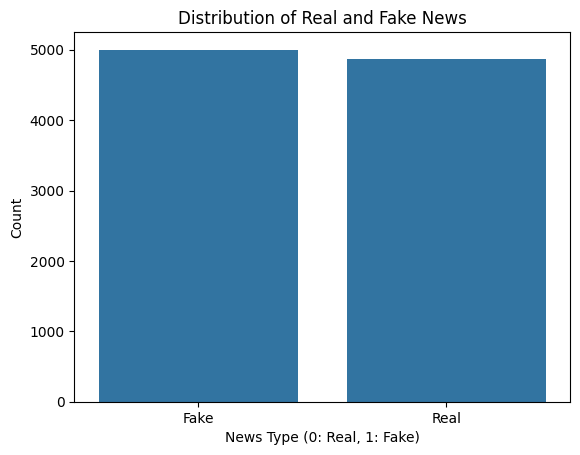

In [30]:
# visulaize the distribution of the target variable
sns.countplot(x='label', data=df)
plt.title('Distribution of Real and Fake News')
plt.xlabel('News Type (0: Real, 1: Fake)')
plt.ylabel('Count')
plt.show()

In [31]:
# Now we will separate the features and the target variable, for further processing and model training
X = df['Text']
y = df['label']

In [32]:
# check x and y shapes
print(X.shape)
print(y.shape)

(9865,)
(9865,)


In [33]:
# encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

In [34]:
#save the label encoder for future use
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

In [35]:
# checking the encoded target variable to see which number is assigned to which label
encoded_labels = dict(zip(le.classes_, le.transform(le.classes_)))
print("Encoded labels (Language → Numeric):\n", encoded_labels)

Encoded labels (Language → Numeric):
 {'Fake': np.int64(0), 'Real': np.int64(1)}


### preprocessing of the data

In [36]:
# laod the stopwaords and lemmatizer for text preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [37]:
# cleaning the text data, removing urls, html tags, special characters, stop words, and lemmatizing the words
def clean_text(text):

    # convert to lowercase
    text = text.lower()

    # remove urls, html tags, and special characters
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # tokenize the text and remove stop words and lemmatize the words
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(tokens)

In [38]:
df['Text'] = df['Text'].apply(clean_text)
df = df[df['Text'].str.strip() != ""]

In [39]:
#check the cleaned text data
print(df.head())

                                                Text label
0  top trump surrogate brutally stab back he path...  Fake
1  conservative leader optimistic common ground h...  Real
2  trump proposes tax overhaul stir concern defic...  Real
3  court force ohio allow million illegally purge...  Fake
4  democrat say trump agrees work immigration bil...  Real


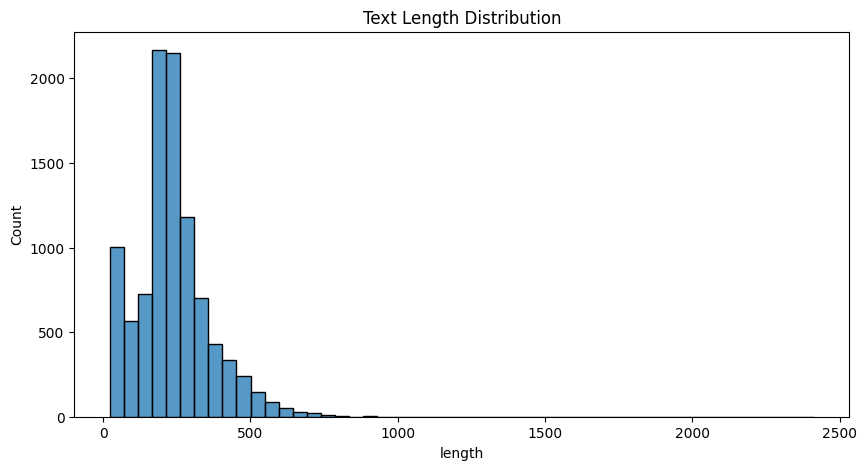

In [40]:
# checkung the distribution of text length in the dataset
df['length'] = df['Text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
sns.histplot(df['length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

In [41]:
# feature extraction using TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['Text'])

In [42]:
# train test split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [43]:
# using pipeline to train multiple models and evaluate their performance
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

In [44]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1": f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1
Logistic Regression,0.993411,0.993416,0.993411,0.993411
Naive Bayes,0.962494,0.962514,0.962494,0.962495
Random Forest,0.999493,0.999494,0.999493,0.999493


In [45]:
# we will choose the best model based on the F1 score and save it for future use
best_model = LogisticRegression()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.99      0.99       973

    accuracy                           0.99      1973
   macro avg       0.99      0.99      0.99      1973
weighted avg       0.99      0.99      0.99      1973



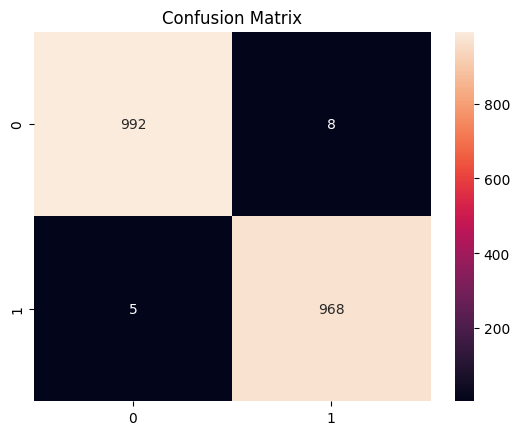

In [47]:
# checking the confusion matrix for the best model
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [48]:
def predict_news(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    
    prediction = best_model.predict(vectorized)[0]
    prob = best_model.predict_proba(vectorized)[0]
    
    label = "Real News ✅" if prediction == 1 else "Fake News 🛑"
    confidence = np.max(prob)
    
    return label, confidence

In [50]:
# Test
news = input("Enter news: ")

label, confidence = predict_news(news)

print(f"Prediction: {label}")
print(f"Confidence: {confidence:.2f}")

Prediction: Fake News 🛑
Confidence: 0.62


In [51]:
# save the model and the vectorizer for future use
with open('fake_news_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [53]:
# this code is used for top fake and real words based on the coefficients of the logistic regression model
feature_names = vectorizer.get_feature_names_out()
coefficients = best_model.coef_[0]

top_fake = np.argsort(coefficients)[:20]
top_real = np.argsort(coefficients)[-20:]

print("Top Fake Words:")
print([feature_names[i] for i in top_fake])

print("\nTop Real Words:")
print([feature_names[i] for i in top_real])

Top Fake Words:
['image', 'via', 'trump', 'even', 'gop', 'like', 'video', 'fact', 'one', 'know', 'obama', 'get', 'people', 'actually', 'thing', 'rep', 'getty', 'time', 'word', 'right']

Top Real Words:
['democratic', 'monday', 'dont', 'comment', 'moscow', 'trade', 'tax', 'told', 'house', 'friday', 'representative', 'wednesday', 'senate', 'thursday', 'edt', 'tuesday', 'president', 'washington', 'reuters', 'said']


In [55]:
# the following code is used for batch prediction on a csv file containing news articles and saving the predictions in a new csv file
def batch_predict(input_file, output_file):
    data = pd.read_csv(input_file)
    
    data['clean_text'] = data['text'].apply(clean_text)
    X = vectorizer.transform(data['clean_text'])
    
    preds = best_model.predict(X)
    
    data['prediction'] = preds
    data.to_csv(output_file, index=False)
    
    print("Batch prediction saved!")